# Visualization of synthesized output

In [1]:
from pathlib import Path

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np

from synthbold.config import Config
from synthbold.io import save_batch
from synthbold.pipeline import SynthPipeline, SynthSample
from synthbold.transforms.functional import zscore


def standardize(s: SynthSample) -> SynthSample:
    """Z-score normalize the field map statistics."""
    return s._replace(
        dbz_mean=zscore(s.dbz_mean),
        dbz_variance=zscore(s.dbz_variance, center=False),
        dbz_skewness=zscore(s.dbz_skewness),
        dbz_kurtosis=zscore(s.dbz_kurtosis),
    )


idx = 0  # batch element to plot
z = 10  # slice to plot
n_sample = 10  # number of generated label samples
batch_size = 4  # number of batch elements to synthesize


out_dir = Path("./batch")
out_dir.mkdir(exist_ok=True, parents=True)

# load default configuration
config = Config()

In [2]:
# instantiate pipeline
indices = None
synth_pipeline = SynthPipeline(
    dirname=out_dir,
    n_samples=n_sample,
    config=config,
    indices=indices,
    include_spheres=False,
    include_tetrahedra=False,
    include_cubes=False,
    include_toroids=False,
)

# Generate batch
sample, _, _ = synth_pipeline(batch_size=batch_size)

# Standardize
sample = standardize(sample)

# Save batch
save_batch(sample._asdict(), out_dir, "nii", "", None)

In [3]:
# parse synthesized data
tissue = sample.tissue[idx][:, :, z].cpu().numpy()
compartment = sample.compartment[idx][:, :, z].cpu().numpy()
magnitude = sample.magnitude[idx][:, :, z].cpu().numpy()
phase = sample.phase[idx][:, :, z].cpu().numpy()

dbz_mean = sample.dbz_mean[idx][:, :, z].cpu().numpy()
dbz_variance = sample.dbz_variance[idx][:, :, z].cpu().numpy()
dbz_skewness = sample.dbz_skewness[idx][:, :, z].cpu().numpy()
dbz_kurtosis = sample.dbz_kurtosis[idx][:, :, z].cpu().numpy()

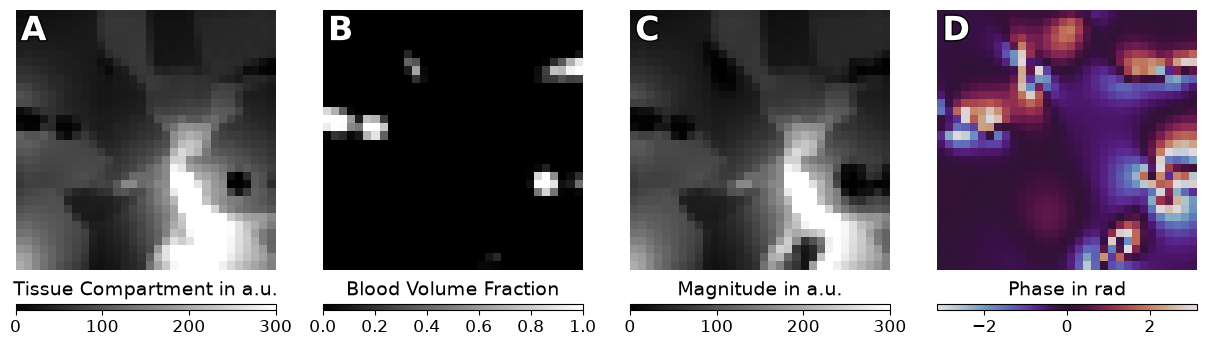

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

plt.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.25, wspace=-0.5)

ims = [
    axes[0].imshow(tissue, cmap="gray", vmin=0.0, vmax=300.0),
    axes[1].imshow(compartment, cmap="gray", vmin=0.0, vmax=1.0),
    axes[2].imshow(magnitude, cmap="gray", vmin=0.0, vmax=300.0),
    axes[3].imshow(phase, cmap="twilight", vmin=-np.pi, vmax=np.pi),
]

cbar_titles = [
    r"Tissue Compartment in a.u.",
    r"Blood Volume Fraction",
    r"Magnitude in a.u.",
    r"Phase in rad",
]

for ax, im, ctitle in zip(axes, ims, cbar_titles, strict=True):
    ax.axis("off")

    pos = ax.get_position()

    cax = fig.add_axes([pos.x0, pos.y0 - 0.10, pos.width, 0.015])

    cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
    cbar.ax.tick_params(labelsize=12)

    cbar.ax.set_title(ctitle, fontsize=14, pad=6)

labels = ["A", "B", "C", "D"]
# labels = ["", "", "", ""]
for ax, label in zip(axes, labels, strict=True):
    txt = ax.text(
        0.02,
        0.98,
        label,
        transform=ax.transAxes,
        fontsize=24,
        fontweight="bold",
        va="top",
        ha="left",
        color="white",
    )
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])

plt.show()
fig.savefig("synth_batch.svg", format="svg", bbox_inches="tight", dpi=300)

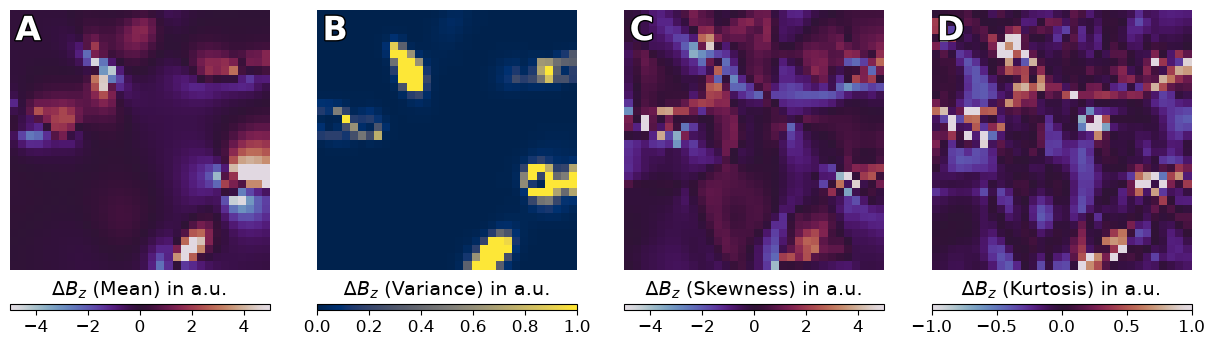

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

plt.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.25, wspace=-0.5)

ims = [
    axes[0].imshow(dbz_mean, cmap="twilight", vmin=-5.0, vmax=5.0),
    axes[1].imshow(dbz_variance, cmap="cividis", vmin=0.0, vmax=1.0),
    axes[2].imshow(dbz_skewness, cmap="twilight", vmin=-5.0, vmax=5.0),
    axes[3].imshow(dbz_kurtosis, cmap="twilight", vmin=-1.0, vmax=1.0),
]

cbar_titles = [
    r"$\Delta B_z$ (Mean) in a.u.",
    r"$\Delta B_z$ (Variance) in a.u.",
    r"$\Delta B_z$ (Skewness) in a.u.",
    r"$\Delta B_z$ (Kurtosis) in a.u.",
]

for ax, im, ctitle in zip(axes, ims, cbar_titles, strict=True):
    ax.axis("off")

    pos = ax.get_position()

    cax = fig.add_axes([pos.x0, pos.y0 - 0.10, pos.width, 0.015])

    cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
    cbar.ax.tick_params(labelsize=12)

    cbar.ax.set_title(ctitle, fontsize=14, pad=6)

labels = ["A", "B", "C", "D"]
# labels = ["", "", "", ""]
for ax, label in zip(axes, labels, strict=True):
    txt = ax.text(
        0.02,
        0.98,
        label,
        transform=ax.transAxes,
        fontsize=24,
        fontweight="bold",
        va="top",
        ha="left",
        color="white",
    )
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="black")])

plt.show()
fig.savefig("dbz_statistics.svg", format="svg", bbox_inches="tight", dpi=300)